# Necessary Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import os
import cv2
import kagglehub

import tensorflow as tf
from tensorflow import keras
from keras import layers, Model
from keras.models import Sequential

from sklearn.model_selection import train_test_split


In [2]:
def combined_loss(y_true, y_pred):
    smooth = 0.00001
    y_true = tf.reshape(y_true, [-1])
    y_pred = tf.reshape(y_pred, [-1])
    intersection = tf.reduce_sum(y_true*y_pred)
    dice = (2.*intersection+smooth)/(tf.reduce_sum(y_true)+tf.reduce_sum(y_pred)+smooth)
    dl = 1.0 - dice

    bce = tf.keras.losses.BinaryCrossentropy()
    bce_loss = bce(y_true, y_pred)
    return dl + bce_loss

# Segmentation Sample

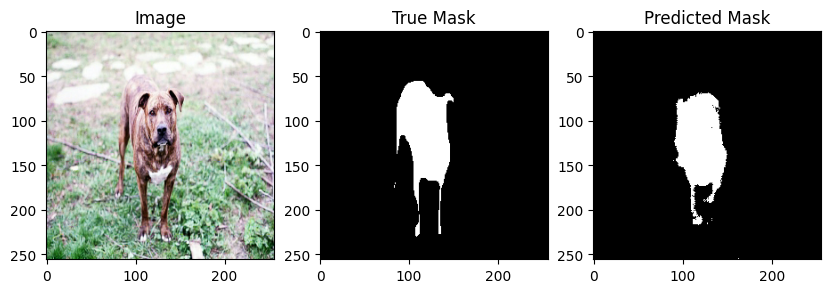

# Data Loading and Processing

In [3]:
path = kagglehub.dataset_download("atikaakter11/brain-tumor-segmentation-dataset")

100%|██████████| 106M/106M [00:05<00:00, 19.3MB/s]

Extracting files...


In [4]:
print(os.listdir(path))
path2 = os.path.join(path, 'Brain Tumor Segmentation Dataset')
print(os.listdir(path2))

image_path = os.path.join(path2, 'image')
mask_path = os.path.join(path2, 'mask')

['Brain Tumor Segmentation Dataset']
['mask', 'image']


<h2> Image
0 - (No Tumor)
1 - (Glioma)
2 - (Meningioma)
3 - (Pituitary) </br>
Mask
0 - (No Tumor)
1 - (Glioma)
2 - (Meningioma)
3 - (Pituitary) </h2>

In [5]:
print(os.listdir(image_path))
print(os.listdir(mask_path))  #['2', '0', '3', '1']

no_tumor_path = os.path.join(image_path, '0')
glioma_path = os.path.join(image_path, '1')
meningioma_path = os.path.join(image_path, '2')
pituitary_path = os.path.join(image_path, '3')

no_tumor_mask_path = os.path.join(mask_path, '0')
glioma_mask_path = os.path.join(mask_path, '1')
meningioma_mask_path = os.path.join(mask_path, '2')

pituitary_mask_path = os.path.join(mask_path, '3')

['0', '3', '1', '2']
['0', '3', '1', '2']


In [6]:
CLASS_NAMES = ['No Tumor', 'Glioma', 'Meningioma', 'Pituitary']

In [7]:
sum = 0
for cl in os.listdir(image_path):
    p = os.path.join(image_path, cl)
    sum += len(os.listdir(p))
print(sum)


4237


In [8]:
sum = 0
for cl in os.listdir(mask_path): #['1', '2',"3", "4"]
    p = os.path.join(image_path, cl)
    sum += len(os.listdir(p))
print(sum)  ## 4237

4237


# Class Classification model

In [ ]:
train_ds = tf.keras.utils.image_dataset_from_directory(
    image_path,
    labels='inferred',
    label_mode='categorical',
    batch_size=32,
    image_size=(256, 256),
    color_mode='grayscale',
    shuffle=True,
    seed=42,
    validation_split=0.2,
    subset='training'
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    image_path,
    labels='inferred',
    label_mode='categorical',
    batch_size=32,
    image_size=(256, 256),
    color_mode='grayscale',
    shuffle=False,
    seed=42,
    validation_split=0.2,
    subset='validation'
)

Found 4237 files belonging to 4 classes.
Using 3390 files for training.
Found 4237 files belonging to 4 classes.
Using 847 files for validation.


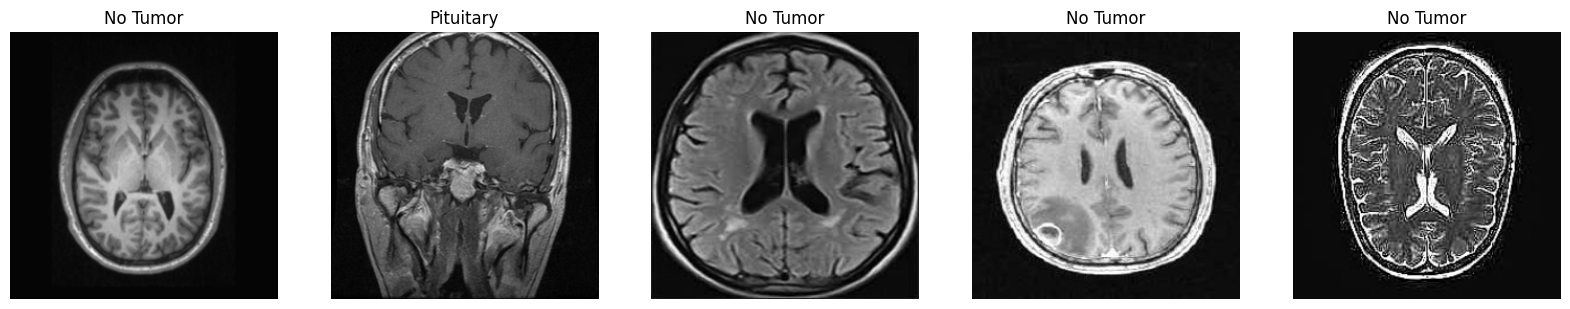

In [ ]:
fig, axis = plt.subplots(1,5,figsize=(20,10))
for image, cl in train_ds.take(1):
    for i in range(5):
        axis[i].imshow(image[i], cmap='gray')
        index = np.argmax(cl[i])
        axis[i].set_title(CLASS_NAMES[index])
        axis[i].axis('off')


In [ ]:
# resize and scale the imge

In [ ]:
# Model Building

tumor_model = tf.keras.models.Sequential([
    layers.Input((256, 256, 1)),

    layers.Conv2D(16, (3,3), padding='same', activation='relu'),
    layers.Conv2D(16, (3,3), padding='same', activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(32, (3,3), padding='same', activation='relu'),
    layers.Conv2D(32, (3,3), padding='same', activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(64, (3,3), padding='same', activation='relu'),
    layers.Conv2D(64, (3,3), padding='same', activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),

    # layers.Conv2D(12, (3,3), padding='same', activation='relu'),
    # layers.Conv2D(16, (3,3), padding='same', activation='relu'),
    # layers.BatchNormalization(),
    # layers.MaxPooling2D((2,2)),
    layers.Flatten(),

    layers.Dense(64, activation='relu'),
    layers.Dense(4, activation='softmax')
])



In [ ]:
print(tumor_model.input_shape)
print(tumor_model.output_shape)

(None, 256, 256, 1)
(None, 4)


In [ ]:
tumor_model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_6 (Conv2D)               │ (None, 256, 256, 16)   │           160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 256, 256, 16)   │         2,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 256, 256, 16)   │            64 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 128, 128, 16)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 128, 128, 32)   │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 128, 128, 32)   │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 128, 128, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_10 (Conv2D)              │ (None, 64, 64, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (None, 64, 64, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 64, 64, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 65536)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │     4,194,368 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 4)              │           260 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,266,868 (16.28 MB)

 Trainable params: 4,266,644 (16.28 MB)

 Non-trainable params: 224 (896.00 B)

In [ ]:
# Compile the model
tumor_model.compile(
    optimizer = tf.keras.optimizers.Adam(learning_rate=0.001),
    loss = tf.keras.losses.CategoricalCrossentropy(),
    metrics=['accuracy']
)

# fit the model
H = tumor_model.fit(
    train_ds,
    validation_data = val_ds,
    batch_size=32,
    epochs=3,
    verbose=1
)



Epoch 1/3
133/133 ━━━━━━━━━━━━━━━━━━━━ 42s 177ms/step - accuracy: 0.7293 - loss: 1.5211
Epoch 2/3
133/133 ━━━━━━━━━━━━━━━━━━━━ 12s 89ms/step - accuracy: 0.8275 - loss: 0.4618
Epoch 3/3
133/133 ━━━━━━━━━━━━━━━━━━━━ 12s 89ms/step - accuracy: 0.9044 - loss: 0.2472


In [ ]:
tumor_model.evaluate(val_ds)

27/27 ━━━━━━━━━━━━━━━━━━━━ 5s 93ms/step - accuracy: 0.9799 - loss: 0.0643


[0.06431583315134048, 0.9799291491508484]

## Handling data mis-match

In [9]:
for class_name in os.listdir(mask_path):
    for file_name in os.listdir(os.path.join(mask_path, class_name)): # files
        if file_name.endswith('_m.jpg'):
            new_file_name = file_name.replace('_m.jpg', '.jpg')
            os.rename(os.path.join(mask_path, class_name, file_name),
                      os.path.join(mask_path, class_name, new_file_name))


In [10]:
os.listdir(mask_path + '/1')[:3]

['Tr-gl_1111.jpg', 'Tr-gl_1292.jpg', 'Tr-gl_0301.jpg']

In [11]:
sum = 0
for class_name in os.listdir(image_path):
    sum+=len(os.listdir(os.path.join(image_path, class_name)))
    for file_name in os.listdir(os.path.join(image_path, class_name)):
        if file_name.endswith('.jpg'):
            continue
        else:
            print(file_name)
print(sum)

4237


In [12]:
print(os.listdir((image_path+'/1'))[:5])
print(os.listdir((mask_path+'/1'))[:5])

['Tr-gl_1111.jpg', 'Tr-gl_1292.jpg', 'Tr-gl_0301.jpg', 'Tr-gl_0528.jpg', 'Tr-gl_0865.jpg']
['Tr-gl_1111.jpg', 'Tr-gl_1292.jpg', 'Tr-gl_0301.jpg', 'Tr-gl_0528.jpg', 'Tr-gl_0865.jpg']


In [13]:
for class_name in os.listdir(image_path):
    num = len(os.listdir(os.path.join(image_path, class_name)))
    print('Number of images: ', class_name, num)
    # for i in range(num):
    image_file_name = os.listdir(os.path.join(image_path, class_name))
    mask_file_name = os.listdir(os.path.join(mask_path, class_name))
    print(len(image_file_name))
    print(len(mask_file_name))


Number of images:  0 1595
1595
1595
Number of images:  3 994
994
994
Number of images:  1 649
649
650
Number of images:  2 999
999
999


In [14]:
# from the above code, there is one extra image in the mask

class1_images = os.listdir(os.path.join(image_path, '1'))
class1_masks = os.listdir(os.path.join(mask_path, '1'))

print(len(class1_images))
print(len(class1_masks))  # before removing the 1 extra image

for file in class1_masks:
    if file not in class1_images:
        index = class1_masks.index(file)  # 227 index
        # remove the mask
        os.remove(os.path.join(mask_path, '1', file))

print(len(class1_masks)) # after removing extra image


649
650
650


In [ ]:
os.listdir(image_path)

['0', '3', '1', '2']

In [15]:
# prepare the image and mask
def full_path_images(image_path, mask_path):
    image_file_paths = []
    mask_file_paths = []
    classes = ["0", "1", "2", "3"]
    for cl in classes:
        for img in sorted(os.listdir(os.path.join(image_path, cl))):
            full_path = os.path.join(image_path, cl, img)
            image_file_paths.append(full_path)

    for cl in classes:
        for mask_img in sorted(os.listdir(os.path.join(mask_path, cl))):
            full_path = os.path.join(mask_path, cl, mask_img)
            mask_file_paths.append(full_path)
    return sorted(image_file_paths), mask_file_paths

images_files_path, mask_files_path = full_path_images(image_path, mask_path)


In [16]:
# prepare the dataset
print(len(images_files_path), len(mask_files_path))  #??????

4237 4237


In [17]:
print(images_files_path[3])
print(mask_files_path[3])

/root/.cache/kagglehub/datasets/atikaakter11/brain-tumor-segmentation-dataset/versions/1/Brain Tumor Segmentation Dataset/image/0/Tr-noTr_0003.jpg
/root/.cache/kagglehub/datasets/atikaakter11/brain-tumor-segmentation-dataset/versions/1/Brain Tumor Segmentation Dataset/mask/0/Tr-noTr_0003.jpg


In [18]:
print(images_files_path[4236])
print(mask_files_path[4236])

/root/.cache/kagglehub/datasets/atikaakter11/brain-tumor-segmentation-dataset/versions/1/Brain Tumor Segmentation Dataset/image/3/Tr-pi_1455.jpg
/root/.cache/kagglehub/datasets/atikaakter11/brain-tumor-segmentation-dataset/versions/1/Brain Tumor Segmentation Dataset/mask/3/Tr-pi_1455.jpg


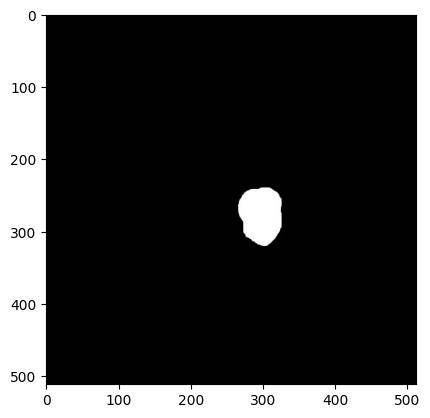

In [19]:
img = cv2.imread(mask_files_path[-10])
img = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
plt.imshow(img, cmap='gray')



In [21]:
def process_images(image_path, mask_path):
    # --- Image ---
    image = tf.io.read_file(image_path)
    image = tf.image.decode_png(image, channels=3)
    image = tf.image.resize(image, [256, 256])
    image = tf.cast(image, tf.float32) / 255.0
    # --- Mask ---
    mask = tf.io.read_file(mask_path)
    mask = tf.image.decode_png(mask, channels=1)
    mask = tf.image.resize(mask, [256, 256], method='nearest')
    mask = tf.cast(mask, tf.float32)
    mask = tf.cast(mask, tf.float32) / 255.0

    # mask = tf.cast(mask > 0.5, tf.float32)
    return image, mask

train_size = int(0.8*len(images_files_path))


train_dataset = tf.data.Dataset.from_tensor_slices(
    (images_files_path[:train_size], mask_files_path[:train_size]))
train_dataset = train_dataset.map(process_images, num_parallel_calls=tf.data.AUTOTUNE)
train_dataset = train_dataset.shuffle(100).batch(32)

test_dataset = tf.data.Dataset.from_tensor_slices(
    (images_files_path[train_size:], mask_files_path[train_size:]))
test_dataset = test_dataset.map(process_images, num_parallel_calls=tf.data.AUTOTUNE)
test_dataset = test_dataset.batch(32)

In [ ]:
print('Number of train batch: ', len(train_dataset))
print("Total number of train-images: ", 32*106)
for imgs, masks in train_dataset.take(2):
    print(imgs.shape)
    print(masks.shape)
    print('=='*20)

Number of train batch:  106
Total number of train-images:  3392
(32, 256, 256, 3)
(32, 256, 256, 1)
(32, 256, 256, 3)
(32, 256, 256, 1)


In [22]:
print('Number of Test Batchs: ', len(test_dataset))
print("Total number of Test-images: ", 32*len(test_dataset))
for imgs, masks in train_dataset.take(2):
    print("Image shape: ", imgs.shape)
    print("Mask shape: ", masks.shape)
    print('=='*20)

Number of Test Batchs:  27
Total number of Test-images:  864
Image shape:  (32, 256, 256, 3)
Mask shape:  (32, 256, 256, 1)
Image shape:  (32, 256, 256, 3)
Mask shape:  (32, 256, 256, 1)


# Visualizing training data


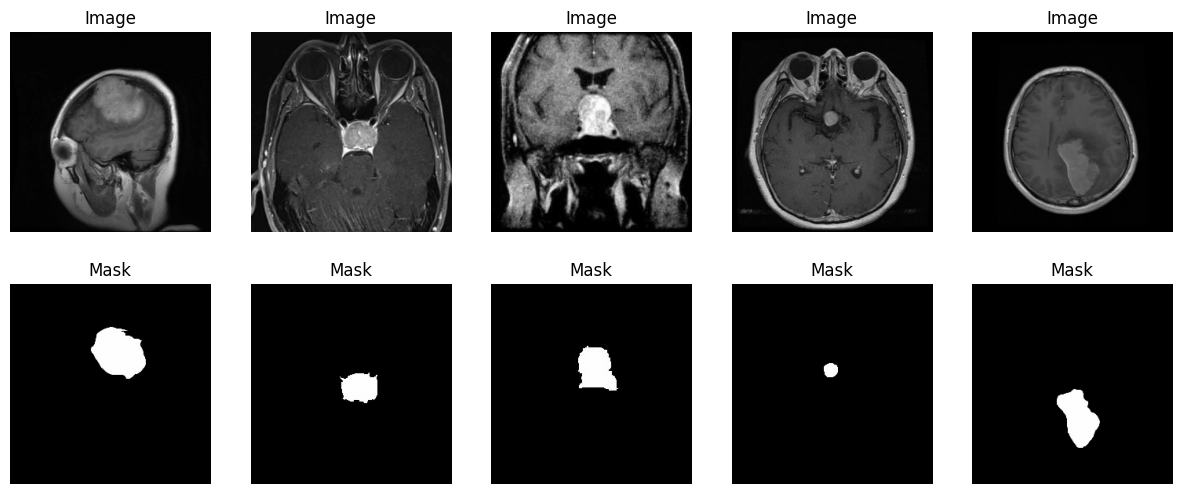

In [24]:

for images, masks in train_dataset.skip(100).take(1):
    imgs = images[:5]
    msks = masks[:5]
    fig, axis = plt.subplots(2,5, figsize=(15, 6))
    for i in range(5):
        axis[0, i].imshow(imgs[i], cmap='gray')
        axis[0, i].set_title('Image')
        axis[0, i].axis('off')

        axis[1, i].imshow(msks[i], cmap='gray')
        axis[1,i].set_title('Mask')
        axis[1, i].axis('off')


# classification and segmentation model customed

In [26]:
# prepring the data---- (images, (class_label, mask image))

def full_path_images(image_path, mask_path):
    image_file_paths = []
    class_labels = []
    mask_file_paths = []
    classes = ["0", "1", "2", "3"]
    for cl in classes:
        for img in sorted(os.listdir(os.path.join(image_path, cl))):
            full_path = os.path.join(image_path, cl, img)
            image_file_paths.append(full_path)

    for cl in classes:
        for mask_img in sorted(os.listdir(os.path.join(mask_path, cl))):
            full_path = os.path.join(mask_path, cl, mask_img)
            mask_file_paths.append(full_path)
            class_labels.append(cl)
    return image_file_paths, (class_labels, mask_file_paths)

image_files_path, target_files_path = full_path_images(image_path, mask_path)


In [27]:
len(image_files_path), len(target_files_path[0])

(4237, 4237)

In [28]:
print("Image Path: ", image_files_path[3010])
print("Mask Path: ", target_files_path[1][3010])
print('Class Label: ', target_files_path[0][3010])
print("Class Name: ", CLASS_NAMES[int(target_files_path[0][3010])])

Image Path:  /root/.cache/kagglehub/datasets/atikaakter11/brain-tumor-segmentation-dataset/versions/1/Brain Tumor Segmentation Dataset/image/2/Tr-me_0892.jpg
Mask Path:  /root/.cache/kagglehub/datasets/atikaakter11/brain-tumor-segmentation-dataset/versions/1/Brain Tumor Segmentation Dataset/mask/2/Tr-me_0892.jpg
Class Label:  2
Class Name:  Meningioma


In [29]:
train_size=int(len(image_files_path)*0.85)
test_size = int(len(image_files_path)*0.05)
val_size = int(len(image_files_path)*0.1)
print("Total number of images: ", len(image_files_path))
print("Train images: ", train_size)
print("Test images: ", test_size)
print("Val Images: ", val_size)

Total number of images:  4237
Train images:  3601
Test images:  211
Val Images:  423


total = 4237

train_data = [:train_size]
test_data = [train_size:train_size+test_size]
val_data = [train_size+test_size:]

In [30]:
target_files_path[1][1]

'/root/.cache/kagglehub/datasets/atikaakter11/brain-tumor-segmentation-dataset/versions/1/Brain Tumor Segmentation Dataset/mask/0/Tr-noTr_0001.jpg'

In [31]:
# Shuffle data-> image_files_path -> target_files_path
print("Full Image lengths ->")
print(len(image_files_path), len(target_files_path[0]), len(target_files_path[1])) #(images, labels. masks)

paired_files = list(zip(image_files_path, target_files_path[0], target_files_path[1])) # (images, labels, masks)
np.random.shuffle(paired_files)  # inplace shuffling


# split_dataset train_size = 80%
train_data = paired_files[:train_size]   #85%
test_data = paired_files[train_size:train_size+test_size]   # 5%
val_data = paired_files[train_size+test_size:]    # 10%

train_images_list, train_labels_str, train_masks_list = zip(*train_data)
test_images_list, test_labels_str, test_masks_list = zip(*test_data)
val_images_list, val_labels_str, val_masks_list = zip(*val_data)

# Convert string labels to integers before zipping into target
train_labels_int = [int(label) for label in train_labels_str]
test_labels_int = [int(label) for label in test_labels_str]
val_labels_int = [int(label) for label in val_labels_str]


# Convert to tf.constant to ensure rank >= 1 for from_tensor_slices
train_images = tf.constant(list(train_images_list))
train_labels_int = tf.constant(train_labels_int)
train_masks = tf.constant(list(train_masks_list))

test_images = tf.constant(list(test_images_list))
test_labels_int = tf.constant(test_labels_int)
test_masks = tf.constant(list(test_masks_list))

val_images = tf.constant(list(val_images_list))
val_labels_int = tf.constant(val_labels_int)
val_masks = tf.constant(list(val_masks_list))

print("Number of training and testing images ->")
print("Train Images: ",len(train_images), "\nTest Images: ", len(test_images), "\nVal Images: ",len(val_images))


Full Image lengths ->
4237 4237 4237
Number of training and testing images ->
Train Images:  3601 
Test Images:  211 
Val Images:  425


In [32]:
def process_images(image_path, class_label, mask_path):
    # process_image
    img = tf.io.read_file(image_path)
    img = tf.image.decode_png(img, channels=3)
    img = tf.image.resize(img, [256, 256])
    img = tf.cast(img, tf.float32) / 255.0

    # process _mask
    mask = tf.io.read_file(mask_path)
    mask = tf.image.decode_png(mask, channels=1)
    mask = tf.image.resize(mask, [256, 256], method='nearest')
    mask = tf.cast(mask, tf.float32)/255.0

    # class_label is already an int here
    one_hot_label = tf.one_hot(class_label, depth=4)

    return img, (one_hot_label, mask)

train_dataset_cs = tf.data.Dataset.from_tensor_slices(
                (train_images, train_labels_int, train_masks))
train_dataset_cs = train_dataset_cs.shuffle(100)
train_dataset_cs = train_dataset_cs.map(lambda img_path, label, mask_path: process_images(img_path, label, mask_path), num_parallel_calls=tf.data.AUTOTUNE)
train_dataset_cs = train_dataset_cs.batch(32)

val_dataset_cs = tf.data.Dataset.from_tensor_slices(
    (val_images, val_labels_int, val_masks))
val_dataset_cs = val_dataset_cs.shuffle(100)
val_dataset_cs = val_dataset_cs.map(lambda img_path, label, mask_path: process_images(img_path, label, mask_path))
val_dataset_cs = val_dataset_cs.batch(32)

test_dataset_cs = tf.data.Dataset.from_tensor_slices(
                (test_images, test_labels_int, test_masks))
test_dataset_cs = test_dataset_cs.map(lambda img_path, label, mask_path: process_images(img_path, label, mask_path), num_parallel_calls=tf.data.AUTOTUNE)
test_dataset_cs = test_dataset_cs.batch(32)


In [33]:
print(train_dataset_cs)
print(val_dataset_cs)
print(test_dataset_cs)


<_BatchDataset element_spec=(TensorSpec(shape=(None, 256, 256, 3), dtype=tf.float32, name=None), (TensorSpec(shape=(None, 4), dtype=tf.float32, name=None), TensorSpec(shape=(None, 256, 256, 1), dtype=tf.float32, name=None)))>
<_BatchDataset element_spec=(TensorSpec(shape=(None, 256, 256, 3), dtype=tf.float32, name=None), (TensorSpec(shape=(None, 4), dtype=tf.float32, name=None), TensorSpec(shape=(None, 256, 256, 1), dtype=tf.float32, name=None)))>
<_BatchDataset element_spec=(TensorSpec(shape=(None, 256, 256, 3), dtype=tf.float32, name=None), (TensorSpec(shape=(None, 4), dtype=tf.float32, name=None), TensorSpec(shape=(None, 256, 256, 1), dtype=tf.float32, name=None)))>


In [34]:
len(train_dataset_cs), len(test_dataset_cs), len(val_dataset_cs)

(113, 7, 14)

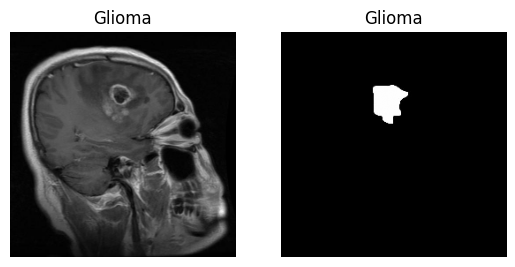

In [39]:
for image, (cl, mask) in test_dataset_cs.skip(6).take(1):
    plt.subplot(1,2,1)
    plt.imshow(image[0], cmap='gray')
    c = tf.argmax(cl[0])  # int
    plt.title(CLASS_NAMES[c])
    plt.axis('off')

    plt.subplot(1,2,2)
    plt.imshow(mask[0], cmap='gray')
    c = tf.argmax(cl[0])  # int
    plt.title(CLASS_NAMES[c])
    plt.axis('off')

In [40]:

def encoding_layer(x, filters, ):
    x = layers.Conv2D(filters, (3,3), padding='same', activation='relu')(x)
    x = layers.Conv2D(filters, (3,3), padding='same', activation='relu')(x)
    x = layers.BatchNormalization()(x)
    p = layers.MaxPooling2D((2,2))(x)
    return x, p   # x-skip connection, p-pooled for next layer

def decoding_layer(x, enco_layer, filters):
    x = layers.Conv2DTranspose(filters, (2,2), strides=(2,2), padding='same', activation='relu')(x)
    x = layers.concatenate([x, enco_layer])
    x = layers.Conv2D(filters, (3,3), padding='same', activation='relu')(x)
    x = layers.Conv2D(filters,(3,3), padding='same', activation='relu')(x)
    return x
def build_unet(input_shape):
    input = layers.Input(input_shape)
    x = layers.Conv2D(8, (3,3), padding='same', activation='relu')(input)

    # ==================== Encoder ====================
    c1, p1 = encoding_layer(x, 16)
    c2, p2 = encoding_layer(p1, 32)
    c3, p3 = encoding_layer(p2, 64)
    c4, p4 = encoding_layer(p3, 128)
    c5, p5 = encoding_layer(p4, 256)

    # ==================== Bottleneck ====================
    b = layers.Conv2D(512, (3,3), padding='same', activation='relu')(p5)
    b = layers.Conv2D(512, (3,3), padding='same', activation='relu')(b)
    b = layers.BatchNormalization()(b)

    # Classification model output here
    c = layers.GlobalAveragePooling2D()(b)
    c = layers.Dense(64, activation='relu')(c)
    output_class = layers.Dense(4, activation='softmax', name="Classification_output")(c)



    # ==================== Decoding ====================
    d1 = decoding_layer(b, c5, 256)
    d2 = decoding_layer(d1, c4, 128)
    d3 = decoding_layer(d2, c3, 64)
    d4 = decoding_layer(d3, c2,32)
    d5 = decoding_layer(d4, c1, 16)

    output_segment = layers.Conv2D(1, (1,1), padding='same', activation='sigmoid', name="Segmentation_output")(d5)

    # but the model have input of 1(images with there class) 2(images and there mask)
    model = tf.keras.Model(inputs=input, outputs=[output_class, output_segment])
    return model

unet_class_segm_v1 = build_unet((256, 256, 3))


In [ ]:
unet_class_segm_v1.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 256, 256,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 256, 256,  │        224 │ input_layer[0][0] │
│                     │ 8)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 256, 256,  │      1,168 │ conv2d[0][0]      │
│                     │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, 256, 256,  │      2,320 │ conv2d_1[0][0]    │
│                     │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 256, 256,  │         64 │ conv2d_2[0][0]    │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d       │ (None, 128, 128,  │          0 │ batch_normalizat… │
│ (MaxPooling2D)      │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_3 (Conv2D)   │ (None, 128, 128,  │      4,640 │ max_pooling2d[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_4 (Conv2D)   │ (None, 128, 128,  │      9,248 │ conv2d_3[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 128, 128,  │        128 │ conv2d_4[0][0]    │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_1     │ (None, 64, 64,    │          0 │ batch_normalizat… │
│ (MaxPooling2D)      │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_5 (Conv2D)   │ (None, 64, 64,    │     18,496 │ max_pooling2d_1[… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_6 (Conv2D)   │ (None, 64, 64,    │     36,928 │ conv2d_5[0][0]    │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 64, 64,    │        256 │ conv2d_6[0][0]    │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_2     │ (None, 32, 32,    │          0 │ batch_normalizat… │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_7 (Conv2D)   │ (None, 32, 32,    │     73,856 │ max_pooling2d_2[… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_8 (Conv2D)   │ (None, 32, 32,    │    147,584 │ conv2d_7[0][0]    │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 32, 32,    │        512 │ conv2d_8[0][0]  

 Total params: 7,813,669 (29.81 MB)

 Trainable params: 7,811,653 (29.80 MB)

 Non-trainable params: 2,016 (7.88 KB)

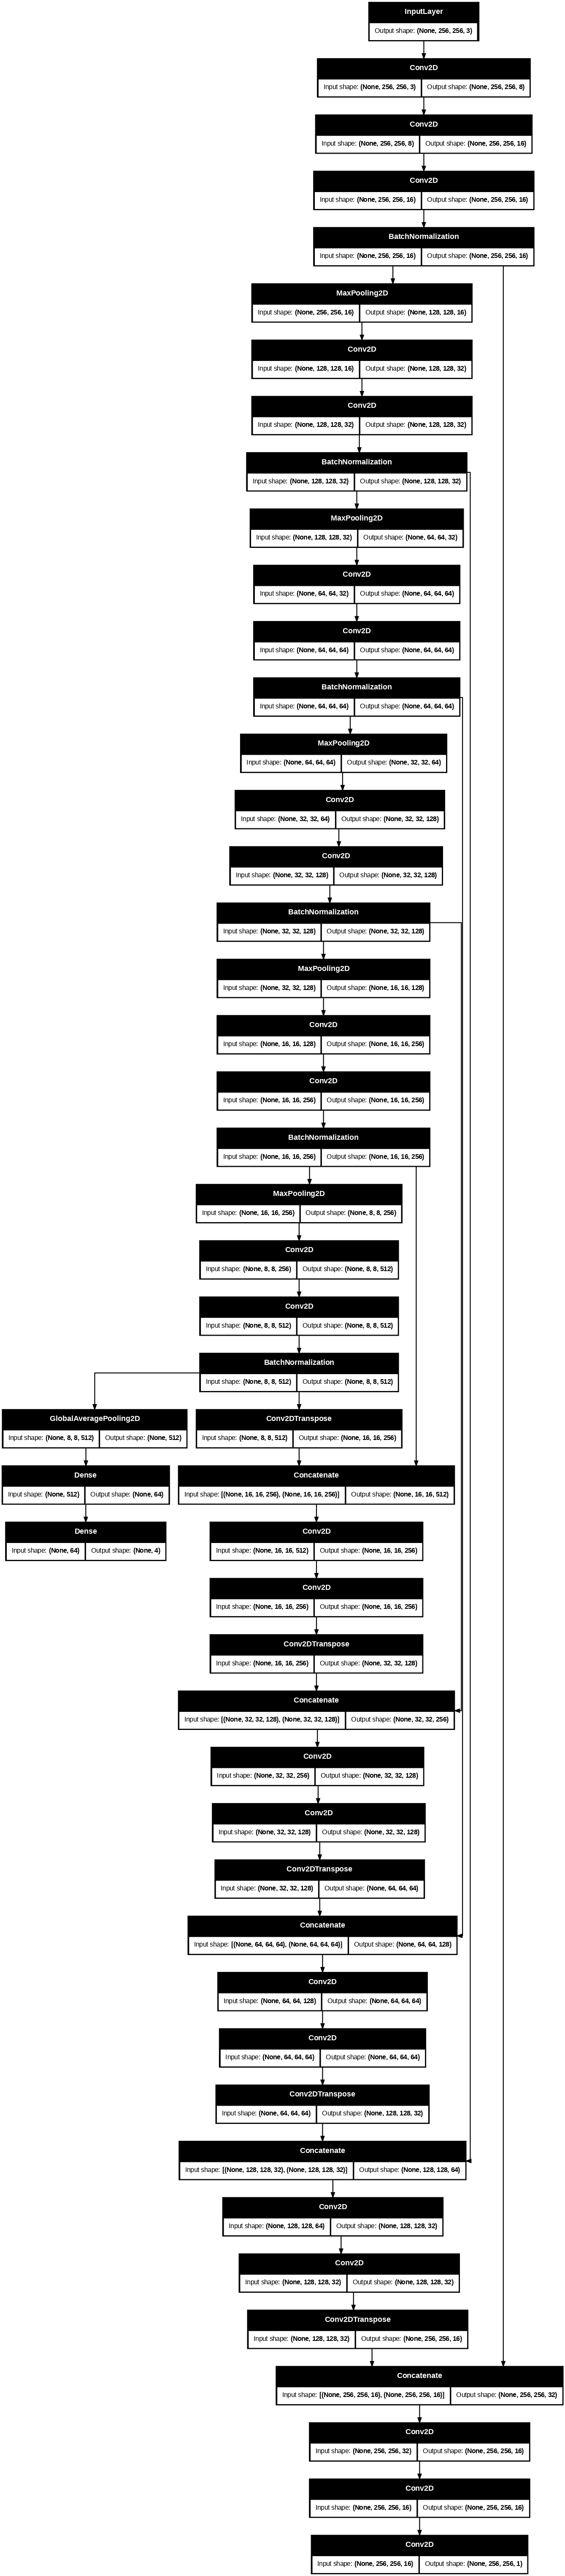

In [ ]:
from keras.utils import plot_model

plot_model(unet_class_segm_v1, show_shapes=True, dpi=80, to_file='images.png')


In [41]:
unet_class_segm_v1.compile(
    optimizer =tf.optimizers.Adam(learning_rate=0.001),
    loss = {
        'Classification_output':tf.keras.losses.CategoricalCrossentropy(),
        "Segmentation_output":combined_loss  # or dice_loss
    },
    metrics=['accuracy', 'accuracy']
)

In [ ]:
# Fit the model
H_cs = unet_class_segm_v1.fit(
    train_dataset_cs,
    validation_data = val_dataset_cs,
    batch_size=32,
    epochs=5,
    verbose=1
)

Epoch 1/5
113/113 ━━━━━━━━━━━━━━━━━━━━ 0s 538ms/step - Classification_output_accuracy: 0.8065 - Classification_output_loss: 0.5075 - Segmentation_output_accuracy: 0.9873 - Segmentation_output_loss: 0.7390 - loss: 1.2465

/usr/local/lib/python3.12/dist-packages/keras/src/backend/tensorflow/nn.py:1286: UserWarning: "`binary_crossentropy` received `from_logits=True`, but the `output` argument was produced by a Sigmoid activation and thus does not represent logits. Was this intended?
  output, from_logits = _get_logits(


113/113 ━━━━━━━━━━━━━━━━━━━━ 69s 615ms/step - Classification_output_accuracy: 0.8262 - Classification_output_loss: 0.4689 - Segmentation_output_accuracy: 0.9864 - Segmentation_output_loss: 0.6561 - loss: 1.1261 - val_Classification_output_accuracy: 0.3435 - val_Classification_output_loss: 5.3773 - val_Segmentation_output_accuracy: 0.9876 - val_Segmentation_output_loss: 1.0891 - val_loss: 6.3218
Epoch 2/5
113/113 ━━━━━━━━━━━━━━━━━━━━ 36s 319ms/step - Classification_output_accuracy: 0.8739 - Classification_output_loss: 0.3423 - Segmentation_output_accuracy: 0.9871 - Segmentation_output_loss: 0.3788 - loss: 0.7217 - val_Classification_output_accuracy: 0.4400 - val_Classification_output_loss: 2.9263 - val_Segmentation_output_accuracy: 0.9849 - val_Segmentation_output_loss: 0.6817 - val_loss: 3.5911
Epoch 3/5
113/113 ━━━━━━━━━━━━━━━━━━━━ 37s 328ms/step - Classification_output_accuracy: 0.9047 - Classification_output_loss: 0.2616 - Segmentation_output_accuracy: 0.9878 - Segmentation_output_l

In [ ]:
unet_class_segm_v1.evaluate(test_dataset_cs)

7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 88ms/step - Classification_output_accuracy: 0.8768 - Classification_output_loss: 0.5493 - Segmentation_output_accuracy: 0.9876 - Segmentation_output_loss: 0.1847 - loss: 0.7464


[0.7463531494140625,
 0.5493083596229553,
 0.1846623420715332,
 0.8767772316932678,
 0.9876366257667542]

In [ ]:
for image, (class_label, mask) in test_dataset_cs.take(2):
    print(image[0].shape)
    print(np.argmax(class_label[0]))
    print(mask[0].shape)
    print('='*20)


(256, 256, 3)
1
(256, 256, 1)
(256, 256, 3)
2
(256, 256, 1)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step


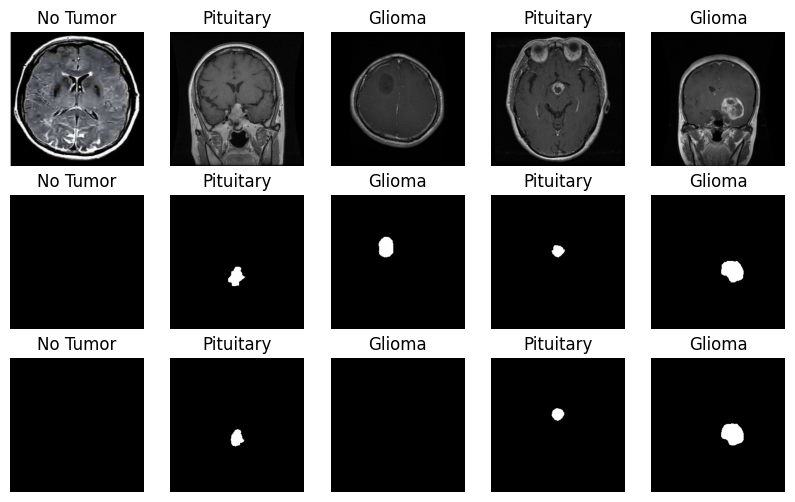

In [ ]:
# test the model
plt.figure(figsize=(10, 6))
for image, (class_label, mask) in test_dataset_cs.skip(6).take(1):
    predictions = unet_class_segm_v1.predict(image) # label and segmented image
    for i in range(5):
        plt.subplot(3,5,i+1)
        plt.imshow(image[i], cmap='gray')
        plt.title(CLASS_NAMES[np.argmax(class_label[i])])
        plt.axis('off')

        plt.subplot(3,5,i+6)
        plt.imshow(mask[i], cmap='gray')
        plt.title(CLASS_NAMES[np.argmax(class_label[i])])
        plt.axis('off')

        plt.subplot(3,5, i+11)
        plt.imshow(predictions[1][i]>0.05, cmap='gray')
        plt.title(CLASS_NAMES[np.argmax(predictions[0][i])])
        plt.axis('off')

# **Using pre trained model for Higher Accuracy**

#***Using Efficient net pre trained model as encoder and used it for classification and using decoding layerof unet for the segmentation model***

In [54]:
import tensorflow as tf
base_model = tf.keras.applications.ResNet50(
    weights='imagenet',
    include_top=False,
    input_shape=(256,256,3)
)
def decoding_layer(x, skip_connection, filters):
    x = layers.UpSampling2D((2,2))(x)
    x = layers.Concatenate()([x, skip_connection])
    x = layers.Conv2D(filters, (3,3), padding='same', activation='relu')(x)
    x = layers.Conv2D(filters, (3,3), padding='same', activation='relu')(x)
    return x
def build_unet():
    # ===== Skip connections =====
    s1 = base_model.get_layer("conv1_relu").output        # 128x128
    s2 = base_model.get_layer("conv2_block3_out").output  # 64x64
    s3 = base_model.get_layer("conv3_block4_out").output  # 32x32
    s4 = base_model.get_layer("conv4_block6_out").output  # 16x16

    # ===== Bottleneck =====
    b = base_model.get_layer("conv5_block3_out").output   # 8x8

    # Classification model part
    c = base_model.output
    c = layers.GlobalAveragePooling2D()(c)
    c = layers.Dense(64, activation='relu')(c)
    class_output = layers.Dense(4, activation='softmax', name='Classification_output')(c)

    # =============== Decoder ====================
    x = decoding_layer(b, s4, 256)# Block 1: 8 → 16
    x = decoding_layer(x, s3, 128)# Block 2: 16 → 32
    x = decoding_layer(x, s2, 64)# Block 3: 32 → 64
    x = decoding_layer(x, s1, 32)# Block 4: 64 → 128
    x = layers.UpSampling2D((2,2))(x)# Final upsample: 128 → 256

    segment_output = layers.Conv2D(1, (1,1), activation='sigmoid', name='Segmentation_output')(x)   #(256, 256, 1)
    resUmodel = Model(inputs=base_model.input, outputs=[class_output, segment_output, ])

    return resUmodel

resUmodel = build_unet()


In [55]:
resUmodel.summary()

Model: "functional_4"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_5       │ (None, 256, 256,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_pad           │ (None, 262, 262,  │          0 │ input_layer_5[0]… │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_conv (Conv2D) │ (None, 128, 128,  │      9,472 │ conv1_pad[0][0]   │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_bn            │ (None, 128, 128,  │        256 │ conv1_conv[0][0]  │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_relu          │ (None, 128, 128,  │          0 │ conv1_bn[0][0]    │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pad           │ (None, 130, 130,  │          0 │ conv1_relu[0][0]  │
│ (ZeroPadding2D)     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pool          │ (None, 64, 64,    │          0 │ pool1_pad[0][0]   │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_conv │ (None, 64, 64,    │      4,160 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_bn   │ (None, 64, 64,    │        256 │ conv2_block1_1_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_relu │ (None, 64, 64,    │          0 │ conv2_block1_1_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_conv │ (None, 64, 64,    │     36,928 │ conv2_block1_1_r… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_bn   │ (None, 64, 64,    │        256 │ conv2_block1_2_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_relu │ (None, 64, 64,    │          0 │ conv2_block1_2_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_conv │ (None, 64, 64,    │     16,640 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_conv │ (None, 64, 64,    │     16,640 │ conv2_block1_2_r… │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_bn   │ (None, 64, 64,    │      1,024 │ conv2_block1_0_c… │
│ (BatchNormalizatio… │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_bn   │ (None, 64, 64,    │      1,024 │ conv2_block1_3_c

 Total params: 32,724,133 (124.83 MB)

 Trainable params: 32,671,013 (124.63 MB)

 Non-trainable params: 53,120 (207.50 KB)

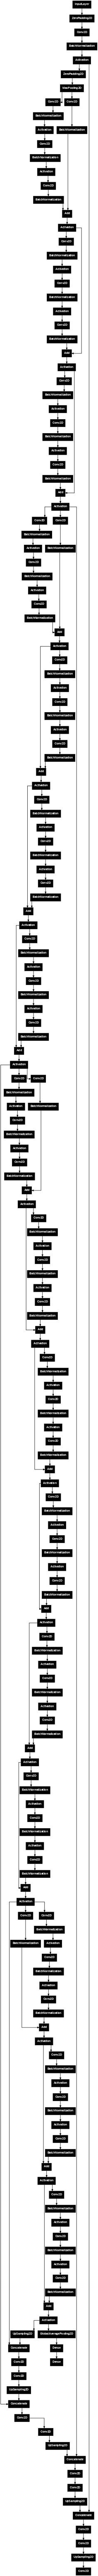

In [44]:
from keras.utils import plot_model

plot_model(resUmodel, to_file='image.png', dpi=30)

# Fit the model for like 30 Epochs

In [56]:
# Compile the model
resUmodel.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss={'Classification_output':combined_loss,
            'Segmentation_output':'binary_crossentropy',
    },
    metrics={
        'Classification_output':'accuracy',
        'Segmentation_output':'accuracy'
    }
)

In [57]:
# Fit / train the model
H = resUmodel.fit(  #0-5 epochs
    train_dataset_cs,
    validation_data = val_dataset_cs,
    batch_size=32,
    epochs=5,
    verbose=1
)

Epoch 1/5
113/113 ━━━━━━━━━━━━━━━━━━━━ 184s 809ms/step - Classification_output_accuracy: 0.8245 - Classification_output_loss: 0.4574 - Segmentation_output_accuracy: 0.9802 - Segmentation_output_loss: 0.0573 - loss: 0.5163 - val_Classification_output_accuracy: 0.2494 - val_Classification_output_loss: 3.5449 - val_Segmentation_output_accuracy: 0.9878 - val_Segmentation_output_loss: 0.1156 - val_loss: 3.6743
Epoch 2/5
113/113 ━━━━━━━━━━━━━━━━━━━━ 87s 539ms/step - Classification_output_accuracy: 0.9061 - Classification_output_loss: 0.2493 - Segmentation_output_accuracy: 0.9873 - Segmentation_output_loss: 0.0249 - loss: 0.2745 - val_Classification_output_accuracy: 0.3671 - val_Classification_output_loss: 4.4673 - val_Segmentation_output_accuracy: 0.9878 - val_Segmentation_output_loss: 0.1816 - val_loss: 4.6313
Epoch 3/5
113/113 ━━━━━━━━━━━━━━━━━━━━ 82s 543ms/step - Classification_output_accuracy: 0.9403 - Classification_output_loss: 0.1658 - Segmentation_output_accuracy: 0.9876 - Segmentati

In [61]:
resUmodel.fit(   # 5-10 epochs
    train_dataset_cs,
    validation_data = val_dataset_cs,
    batch_size=32,
    epochs=5,
    verbose=1
)

Epoch 1/5
113/113 ━━━━━━━━━━━━━━━━━━━━ 60s 527ms/step - Classification_output_accuracy: 0.9758 - Classification_output_loss: 0.0724 - Segmentation_output_accuracy: 0.9879 - Segmentation_output_loss: 0.0117 - loss: 0.0842 - val_Classification_output_accuracy: 0.3671 - val_Classification_output_loss: 2.7049 - val_Segmentation_output_accuracy: 0.9877 - val_Segmentation_output_loss: 0.0833 - val_loss: 2.7683
Epoch 2/5
113/113 ━━━━━━━━━━━━━━━━━━━━ 61s 539ms/step - Classification_output_accuracy: 0.9745 - Classification_output_loss: 0.0697 - Segmentation_output_accuracy: 0.9880 - Segmentation_output_loss: 0.0108 - loss: 0.0808 - val_Classification_output_accuracy: 0.4659 - val_Classification_output_loss: 1.8414 - val_Segmentation_output_accuracy: 0.9421 - val_Segmentation_output_loss: 0.1055 - val_loss: 1.9402
Epoch 3/5
113/113 ━━━━━━━━━━━━━━━━━━━━ 61s 538ms/step - Classification_output_accuracy: 0.9822 - Classification_output_loss: 0.0505 - Segmentation_output_accuracy: 0.9881 - Segmentatio

In [64]:
resUmodel.fit( #10-20 epochs
    train_dataset_cs,
    validation_data = val_dataset_cs,
    batch_size=32,
    epochs=20,
    verbose=1
)

Epoch 1/20
113/113 ━━━━━━━━━━━━━━━━━━━━ 62s 544ms/step - Classification_output_accuracy: 0.9917 - Classification_output_loss: 0.0270 - Segmentation_output_accuracy: 0.9883 - Segmentation_output_loss: 0.0077 - loss: 0.0348 - val_Classification_output_accuracy: 0.9082 - val_Classification_output_loss: 0.3433 - val_Segmentation_output_accuracy: 0.9870 - val_Segmentation_output_loss: 0.0116 - val_loss: 0.3123
Epoch 2/20
113/113 ━━━━━━━━━━━━━━━━━━━━ 81s 541ms/step - Classification_output_accuracy: 0.9911 - Classification_output_loss: 0.0275 - Segmentation_output_accuracy: 0.9883 - Segmentation_output_loss: 0.0080 - loss: 0.0356 - val_Classification_output_accuracy: 0.8494 - val_Classification_output_loss: 0.5181 - val_Segmentation_output_accuracy: 0.9880 - val_Segmentation_output_loss: 0.0191 - val_loss: 0.5335
Epoch 3/20
113/113 ━━━━━━━━━━━━━━━━━━━━ 61s 537ms/step - Classification_output_accuracy: 0.9897 - Classification_output_loss: 0.0335 - Segmentation_output_accuracy: 0.9884 - Segmenta

In [65]:
resUmodel.evaluate(test_dataset_cs)

7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 156ms/step - Classification_output_accuracy: 0.9100 - Classification_output_loss: 0.2706 - Segmentation_output_accuracy: 0.9900 - Segmentation_output_loss: 0.0121 - loss: 0.2981


[0.2981216013431549,
 0.2705741822719574,
 0.012067208997905254,
 0.9099525809288025,
 0.9900248646736145]

#Evaluate the model and Testing the model

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 87ms/step


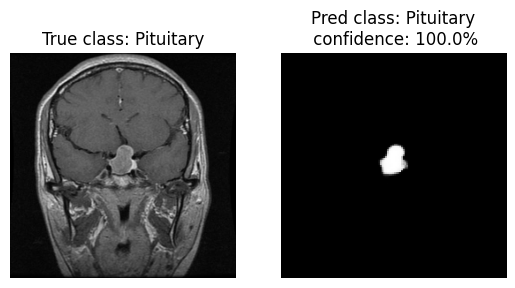

In [104]:
# test with one sample image
for image, (class_label, mask) in test_dataset_cs.take(1):
    true_class = CLASS_NAMES[np.argmax(class_label[0])]
    predictions = resUmodel.predict(image)

    pred_class = CLASS_NAMES[np.argmax(predictions[0][0])]    #
    class_confidence = np.max(predictions[0][0]).round(2)*100
    pred_mask = predictions[1][0]

    plt.subplot(1,2,1)
    plt.imshow(image[0], cmap='gray')
    plt.title(f'True class: {true_class}')
    plt.axis('off')

    plt.subplot(1,2,2)
    plt.imshow(pred_mask, cmap='gray')
    plt.title(f'Pred class: {pred_class}\n confidence: {class_confidence}%')
    plt.axis('off')


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 101ms/step


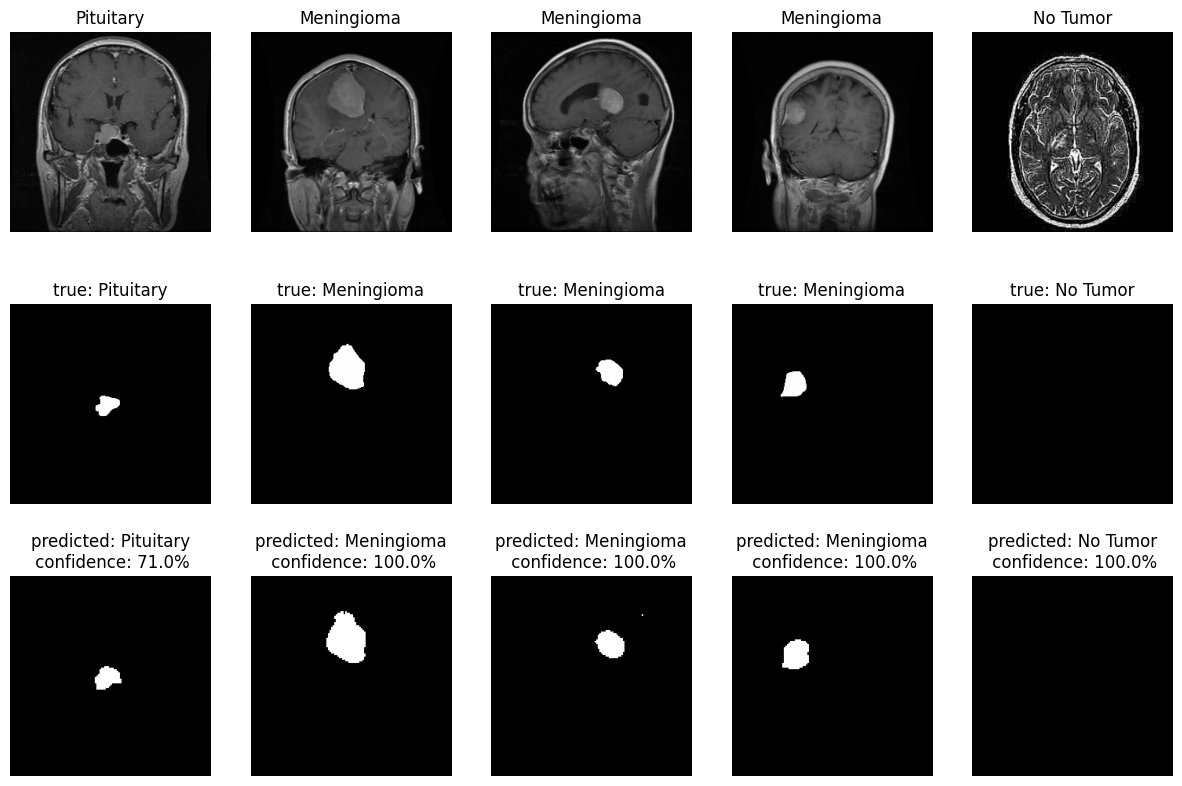

In [114]:
# test the model
plt.figure(figsize=(15, 10))
for image, (class_label, mask) in test_dataset_cs.skip(4).take(1):
    predictions = resUmodel.predict(image) # label and segmented image
    for i in range(5):
        conf = np.max(predictions[0][i]).round(2)*100

        plt.subplot(3,5,i+1)
        plt.imshow(image[i], cmap='gray')
        plt.title(CLASS_NAMES[np.argmax(class_label[i])])
        plt.axis('off')

        plt.subplot(3,5,i+6)
        plt.imshow(mask[i], cmap='gray')
        plt.title(f'true: {CLASS_NAMES[np.argmax(class_label[i])]}')
        plt.axis('off')
        plt.subplot(3,5, i+11)
        plt.imshow(predictions[1][i]>0.05, cmap='gray')
        plt.title(f'predicted: {CLASS_NAMES[np.argmax(predictions[0][i])]}\n confidence: {conf}%')
        plt.axis('off')

# Save and Download the Model

In [115]:
# save the model
resUmodel.save('resUnet_model.keras')

In [116]:
# download to local machine
from google.colab import files
files.download('resUnet_model.keras')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

#